In [1]:
from analyzer import * 

ss = SpubenchResults()  # pd.read_csv('/home/work/yuna/HPA/evaluation/analysis/old/sputbench.csv') 
df = ss.results  

dd, pv = ss.finetuning_effect(df)
# df, pv = ss.finetuning_effect(df) 
# df.groupby(['model', 'condition'])['output'].count().reset_index()

dd = dd[dd['finetuned']!='JS-Blind VQA (n=10)']
dd[dd['trained_dataset']=='MMStar'].pivot_table(
            index=['trained_dataset', 'model', 'strategy'],  #  , 'finetuned' 
            columns=['bias'] , 
            values=['delta']).assign(Average=lambda x: x.mean(axis=1)).reset_index(level=0, drop=True).to_latex('./tables/spubench-mmstar_finetuned-delta.tex', float_format="%.2f")
             
dd[dd['trained_dataset']=='VQA'].pivot_table(
            index=['trained_dataset', 'model', 'strategy', 'blind'],  #  , 'finetuned' 
            columns=['bias'] , 
            values=['delta']).assign(Average=lambda x: x.mean(axis=1)).reset_index(level=0, drop=True).to_latex('./tables/spubench-VQA_finetuned-delta.tex', float_format="%.2f")
dd.trained_dataset.unique(), dd.finetuned.unique() 

/home/work/.anaconda/envs/privacyovod_new_copy/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


cannot find matching /home/work/yuna/HPA/evaluation/scored/pretrained/Qwen3-1.7B/spubench_inst_blind.jsonl in ['InternVL3_5-8B', 'InternVL3_5-4B', 'InternVL3_5-2B', 'InternVL3_5-1B', 'Qwen3-VL-2B-Instruct', 'Qwen3-VL-4B-Instruct', 'Qwen3-VL-8B-Instruct', 'llava-v1.6-vicuna-7b-hf', 'llava-v1.6-mistral-7b-hf', 'llava-1.5-7b-hf', 'Qwen3-4B-Base', 'Qwen3-0.6B-Base', 'Qwen3-8B-Base', 'Qwen3-4B', 'Qwen3-0.6B', 'Qwen3-8B']
cannot unpack non-iterable NoneType object
[]


(array(['VQA', 'MMStar'], dtype=object),
 array(['JS VQA (GT)', 'SFT-Blind MMStar (n=15)', 'JS-Blind VQA (n=15)',
        'JS-Blind MMStar (n=15)', 'SFT-Blind VQA', 'SFT-VQA',
        'SFT-Blind MMStar'], dtype=object))

In [ ]:
from utils.plots import get_heatmap, get_barplot   

def delta_gt_blind_training(df, value='correct', baseline='GT'):  
    pivot_gt = df[(df['blind']==baseline)].pivot_table(
        index=['model'],
        columns='bias',
        values=value
    )
    # Calculate pivot table for JS, Blind
    pivot_blind = df[(df['blind']=='Blind')].pivot_table(
        index=['model'],
        columns='bias',
        values=value 
    )
    return pivot_gt, pivot_blind 

In [86]:
baseline= ss.results
baseline['blind'] = "Pretrained"  

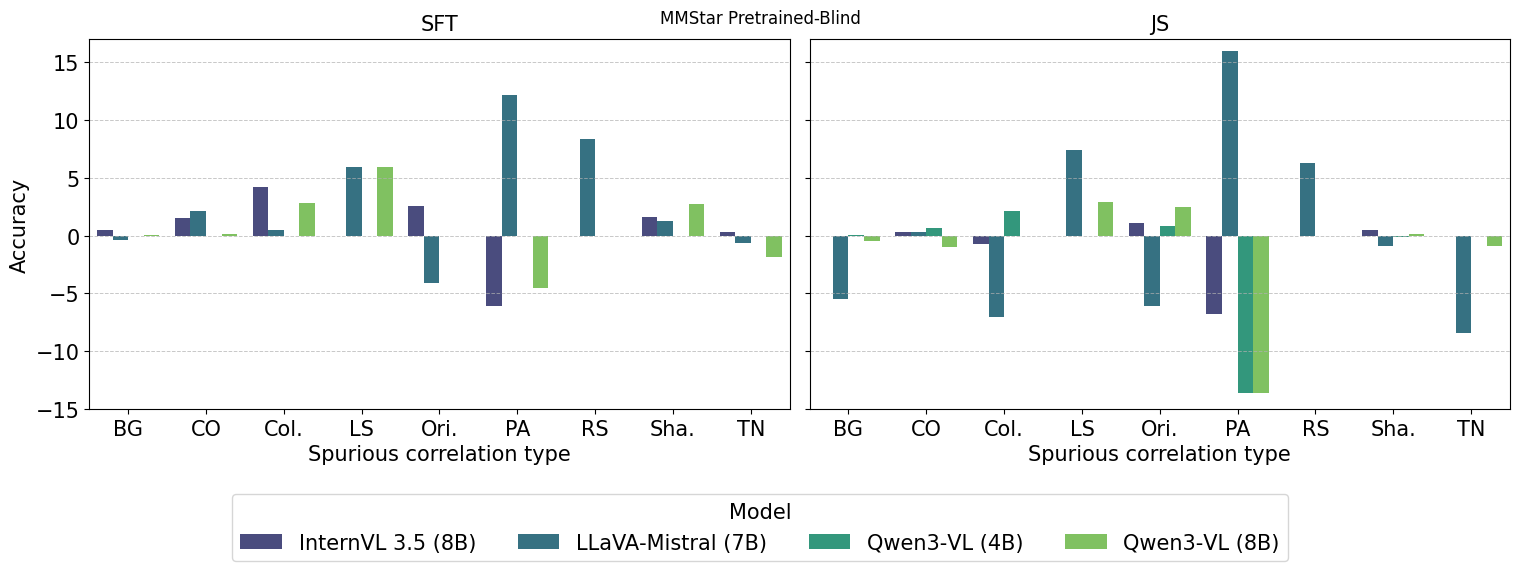

value                                          \
Spurious correlation type        BG        CO      Col.        LS      Ori.   
model                                                                         
InternVL 3.5 (8B)         -0.016057  0.271739 -0.704225  0.000000  1.111111   
LLaVA‑Mistral (7B)        -5.507386  0.339674 -7.042254  7.352941 -6.111111   
Qwen3‑VL (4B)              0.045278  0.679624  2.112676  0.000000  0.833333   
Qwen3‑VL (8B)             -0.465639 -0.951087  0.000000  2.941176  2.500000   

                                                                
Spurious correlation type         PA    RS      Sha.        TN  
model                                                           
InternVL 3.5 (8B)          -6.818182  0.00  0.460123  0.000000  
LLaVA‑Mistral (7B)         15.909091  6.25 -0.920245 -8.411215  
Qwen3‑VL (4B)             -13.636364  0.00 -0.122319  0.000000  
Qwen3‑VL (8B)             -13.636364  0.00  0.153374 -0.934579

In [147]:
mmstar_df = pd.concat([dd[dd['trained_dataset']!='VQA'], baseline]) 
js_pivot_gt, js_pivot_blind =  delta_gt_blind_training(mmstar_df[mmstar_df['strategy']=='JS'], 'correct', 'Pretrained') 
sft_pivot_gt, sft_pivot_blind = delta_gt_blind_training(mmstar_df[mmstar_df['strategy']=='SFT'], 'correct', 'Pretrained')

sft, js = get_barplot(sft_pivot_gt - sft_pivot_blind, js_pivot_gt - js_pivot_blind, 
                        title="MMStar Pretrained-Blind", title1='SFT', title2='JS')  
sft.pivot(index='model', columns=['Spurious correlation type']) 
js.pivot(index='model', columns=['Spurious correlation type']) 

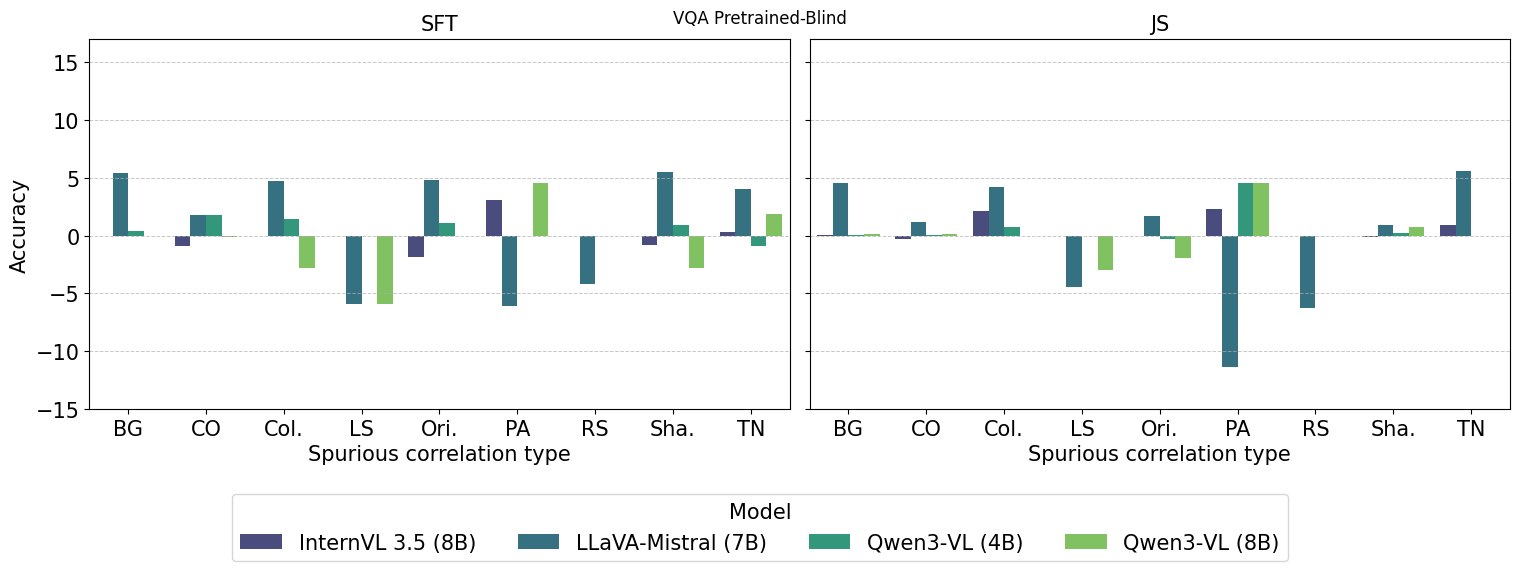

value                                          \
Spurious correlation type        BG        CO      Col.        LS      Ori.   
model                                                                         
InternVL 3.5 (8B)         -0.021409 -0.905797  0.000000  0.000000 -1.851852   
LLaVA‑Mistral (7B)         5.373582  1.811594  4.694836 -5.882353  4.814815   
Qwen3‑VL (4B)              0.353243  1.766304  1.408451  0.000000  1.111111   
Qwen3‑VL (8B)             -0.064226 -0.135870 -2.816901 -5.882353  0.000000   

                                                                   
Spurious correlation type        PA        RS      Sha.        TN  
model                                                              
InternVL 3.5 (8B)          3.030303  0.000000 -0.817996  0.311526  
LLaVA‑Mistral (7B)        -6.060606 -4.166667  5.521472  4.049844  
Qwen3‑VL (4B)              0.000000  0.000000  0.920245 -0.934579  
Qwen3‑VL (8B)              4.545455  0.000000 -2.760736  1.869159

In [151]:
df = dd[dd['trained_dataset']=='VQA'] 
df = pd.concat([df, baseline]) 

baseline_model='Pretrained'
js_pivot_gt, js_pivot_blind =  delta_gt_blind_training(df[df['strategy']=='JS'], 'correct', baseline_model) 
sft_pivot_gt, sft_pivot_blind = delta_gt_blind_training(df[df['strategy']=='SFT'], 'correct', baseline_model)

sft, js = get_barplot(sft_pivot_gt - sft_pivot_blind,  
                       js_pivot_gt - js_pivot_blind, 
                        title="VQA Pretrained-Blind", title1='SFT', title2='JS')  
js.pivot(index='model', columns=['Spurious correlation type']) 
sft.pivot(index='model', columns=['Spurious correlation type']) 

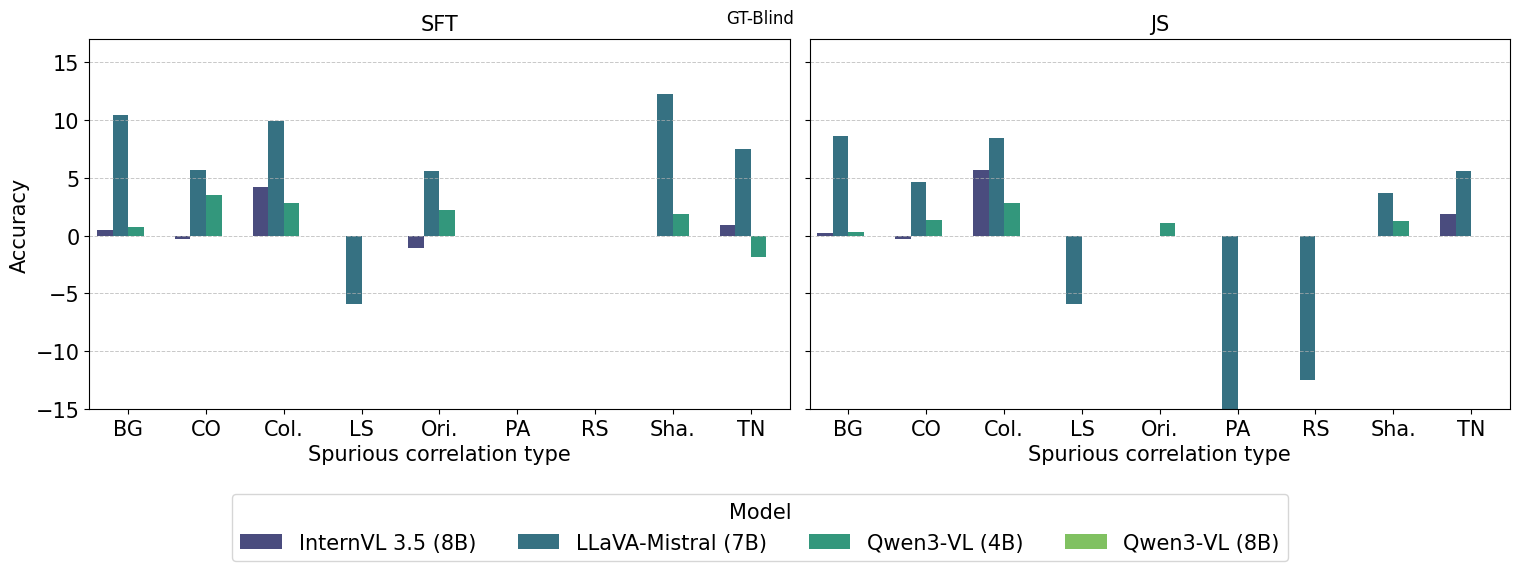

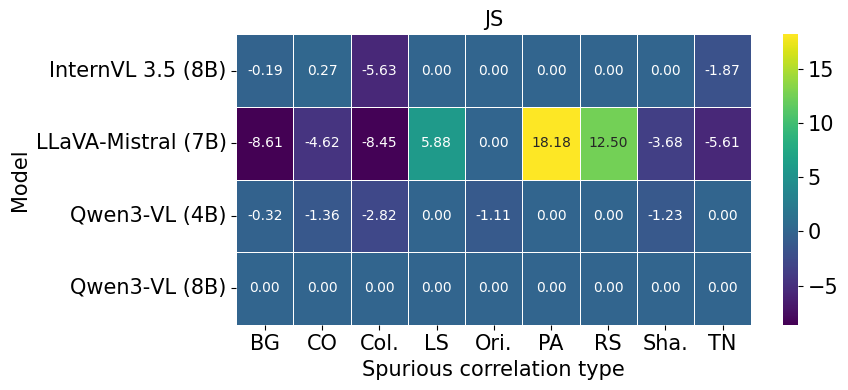

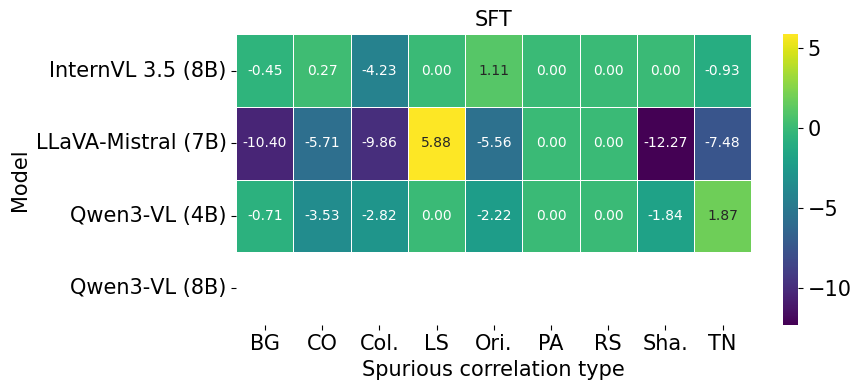

In [ ]:

js_pivot_gt, js_pivot_blind =  delta_gt_blind_training(df[df['strategy']=='JS'], 'correct') 
sft_pivot_gt, sft_pivot_blind = delta_gt_blind_training(df[df['strategy']=='SFT'], 'correct')
 
sft, js = get_barplot(sft_pivot_gt - sft_pivot_blind,  
                       js_pivot_gt - js_pivot_blind, 
                        title="GT-Blind", title1='SFT', title2='JS')  
# Delta values 
js_delta_pivot_gt, js_delta_pivot_blind =  delta_gt_blind_training(df[df['strategy']=='JS'], 'delta') 
sft_delta_pivot_gt, sft_delta_pivot_blind = delta_gt_blind_training(df[df['strategy']=='SFT'], 'delta')
get_heatmap(js_delta_pivot_blind - js_delta_pivot_gt, title='JS')
get_heatmap(sft_delta_pivot_blind - sft_delta_pivot_gt, title='SFT')


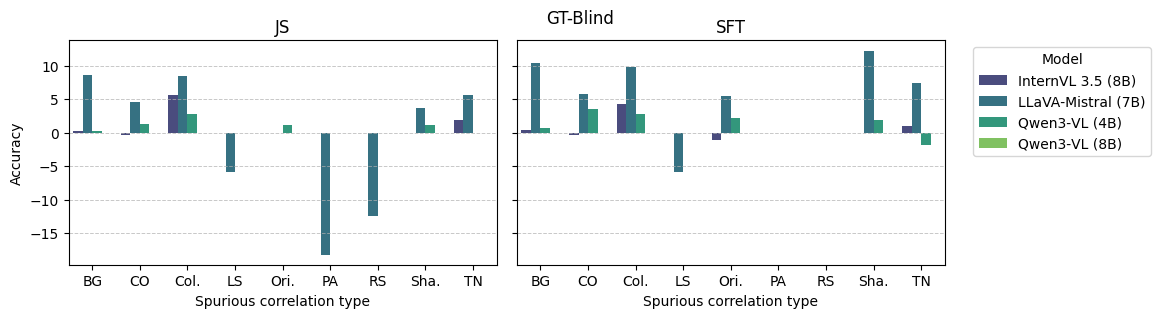

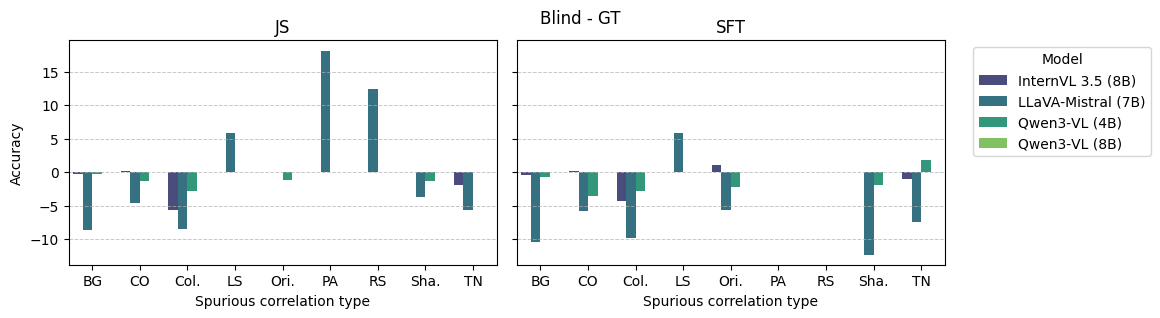

In [42]:
sft, js = get_barplot(js_delta_pivot_gt - js_delta_pivot_blind, 
                       sft_delta_pivot_gt - sft_delta_pivot_blind, 
                        title="GT-Blind", title1='JS', title2='SFT')  

sft, js = get_barplot(js_delta_pivot_blind - js_delta_pivot_gt, 
                       sft_delta_pivot_blind - sft_delta_pivot_gt, 
                        title="Blind - GT", title1='JS', title2='SFT')  

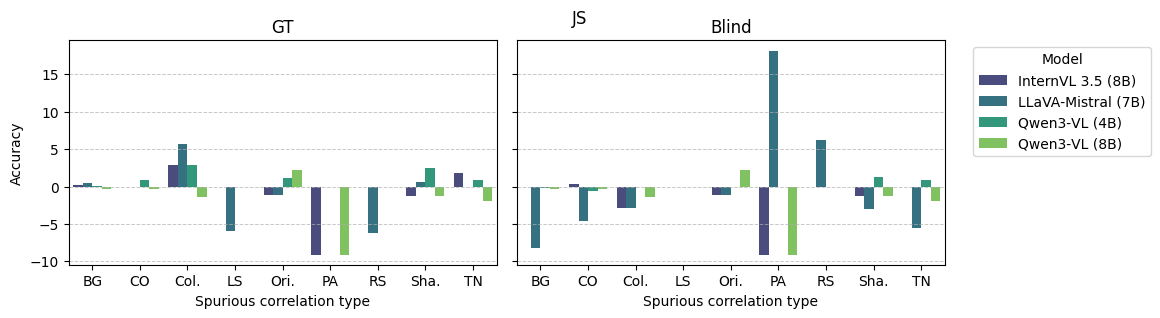

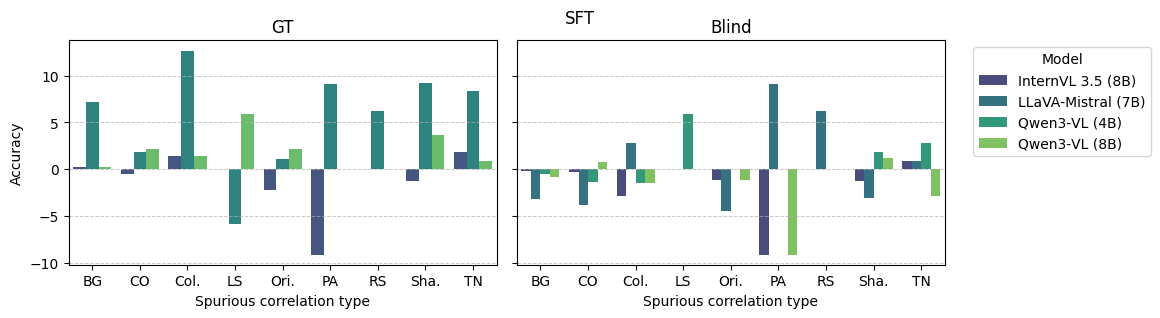

In [38]:
sft, js = get_barplot(js_delta_pivot_gt, js_delta_pivot_blind, title="JS", title1='GT', title2='Blind')  
sft, js = get_barplot(sft_delta_pivot_gt, sft_delta_pivot_blind, title="SFT", title1='GT', title2='Blind')  

In [25]:
js.pivot_table(index=['model'], columns='Spurious correlation type')  

value                                          \
Spurious correlation type        BG        CO      Col.        LS      Ori.   
model                                                                         
InternVL 3.5 (8B)          0.192678 -0.271739  5.633803  0.000000  0.000000   
LLaVA‑Mistral (7B)         8.606294  4.619565  8.450704 -5.882353  0.000000   
Qwen3‑VL (4B)              0.321130  1.358696  2.816901  0.000000  1.111111   
Qwen3‑VL (8B)              0.000000  0.000000  0.000000  0.000000  0.000000   

                                                                
Spurious correlation type         PA    RS      Sha.        TN  
model                                                           
InternVL 3.5 (8B)           0.000000   0.0  0.000000  1.869159  
LLaVA‑Mistral (7B)        -18.181818 -12.5  3.680982  5.607477  
Qwen3‑VL (4B)               0.000000   0.0  1.226994  0.000000  
Qwen3‑VL (8B)               0.000000   0.0  0.000000  0.000000

In [ ]:
df[df['strategy']=='JS'].pivot_table(index=['model', 'blind'], 
            columns='bias', 
            values='correct')

In [33]:
dd[dd['trained_dataset']=='VQA'].pivot_table(
            index=['trained_dataset', 'model', 'blind' ],  # , 'finetuned' 
            columns=['strategy'], # 'bias'] , 
            values=['correct', 'delta'])

correct                delta  \
strategy                                         JS        SFT        JS   
trained_dataset model              blind                                   
VQA             InternVL 3.5 (8B)  Blind  78.000000  77.833333 -0.208333   
                                   GT     78.333333  78.208333  0.125000   
                LLaVA‑Mistral (7B) Blind  56.500000  60.125000 -6.458333   
                                   GT     63.333333  69.375000  0.375000   
                Qwen3‑VL (4B)      Blind  74.500000  74.333333 -0.083333   
                                   GT     75.125000  75.541667  0.541667   
                Qwen3‑VL (8B)      Blind  78.083333  78.000000 -0.458333   
                                   GT     78.083333        NaN -0.458333   

                                                    
strategy                                       SFT  
trained_dataset model              blind            
VQA             InternVL 3.5 (8B)  Blind -0.375000  
                                   GT     0.000000  
                LLaVA‑Mistral (7B) Blind -2.833333  
                                   GT     6.416667  
                Qwen3‑VL (4B)      Blind -0.250000  
                                   GT     0.958333  
                Qwen3‑VL (8B)      Blind -0.541667  
                                   GT          NaN

### Correlations 

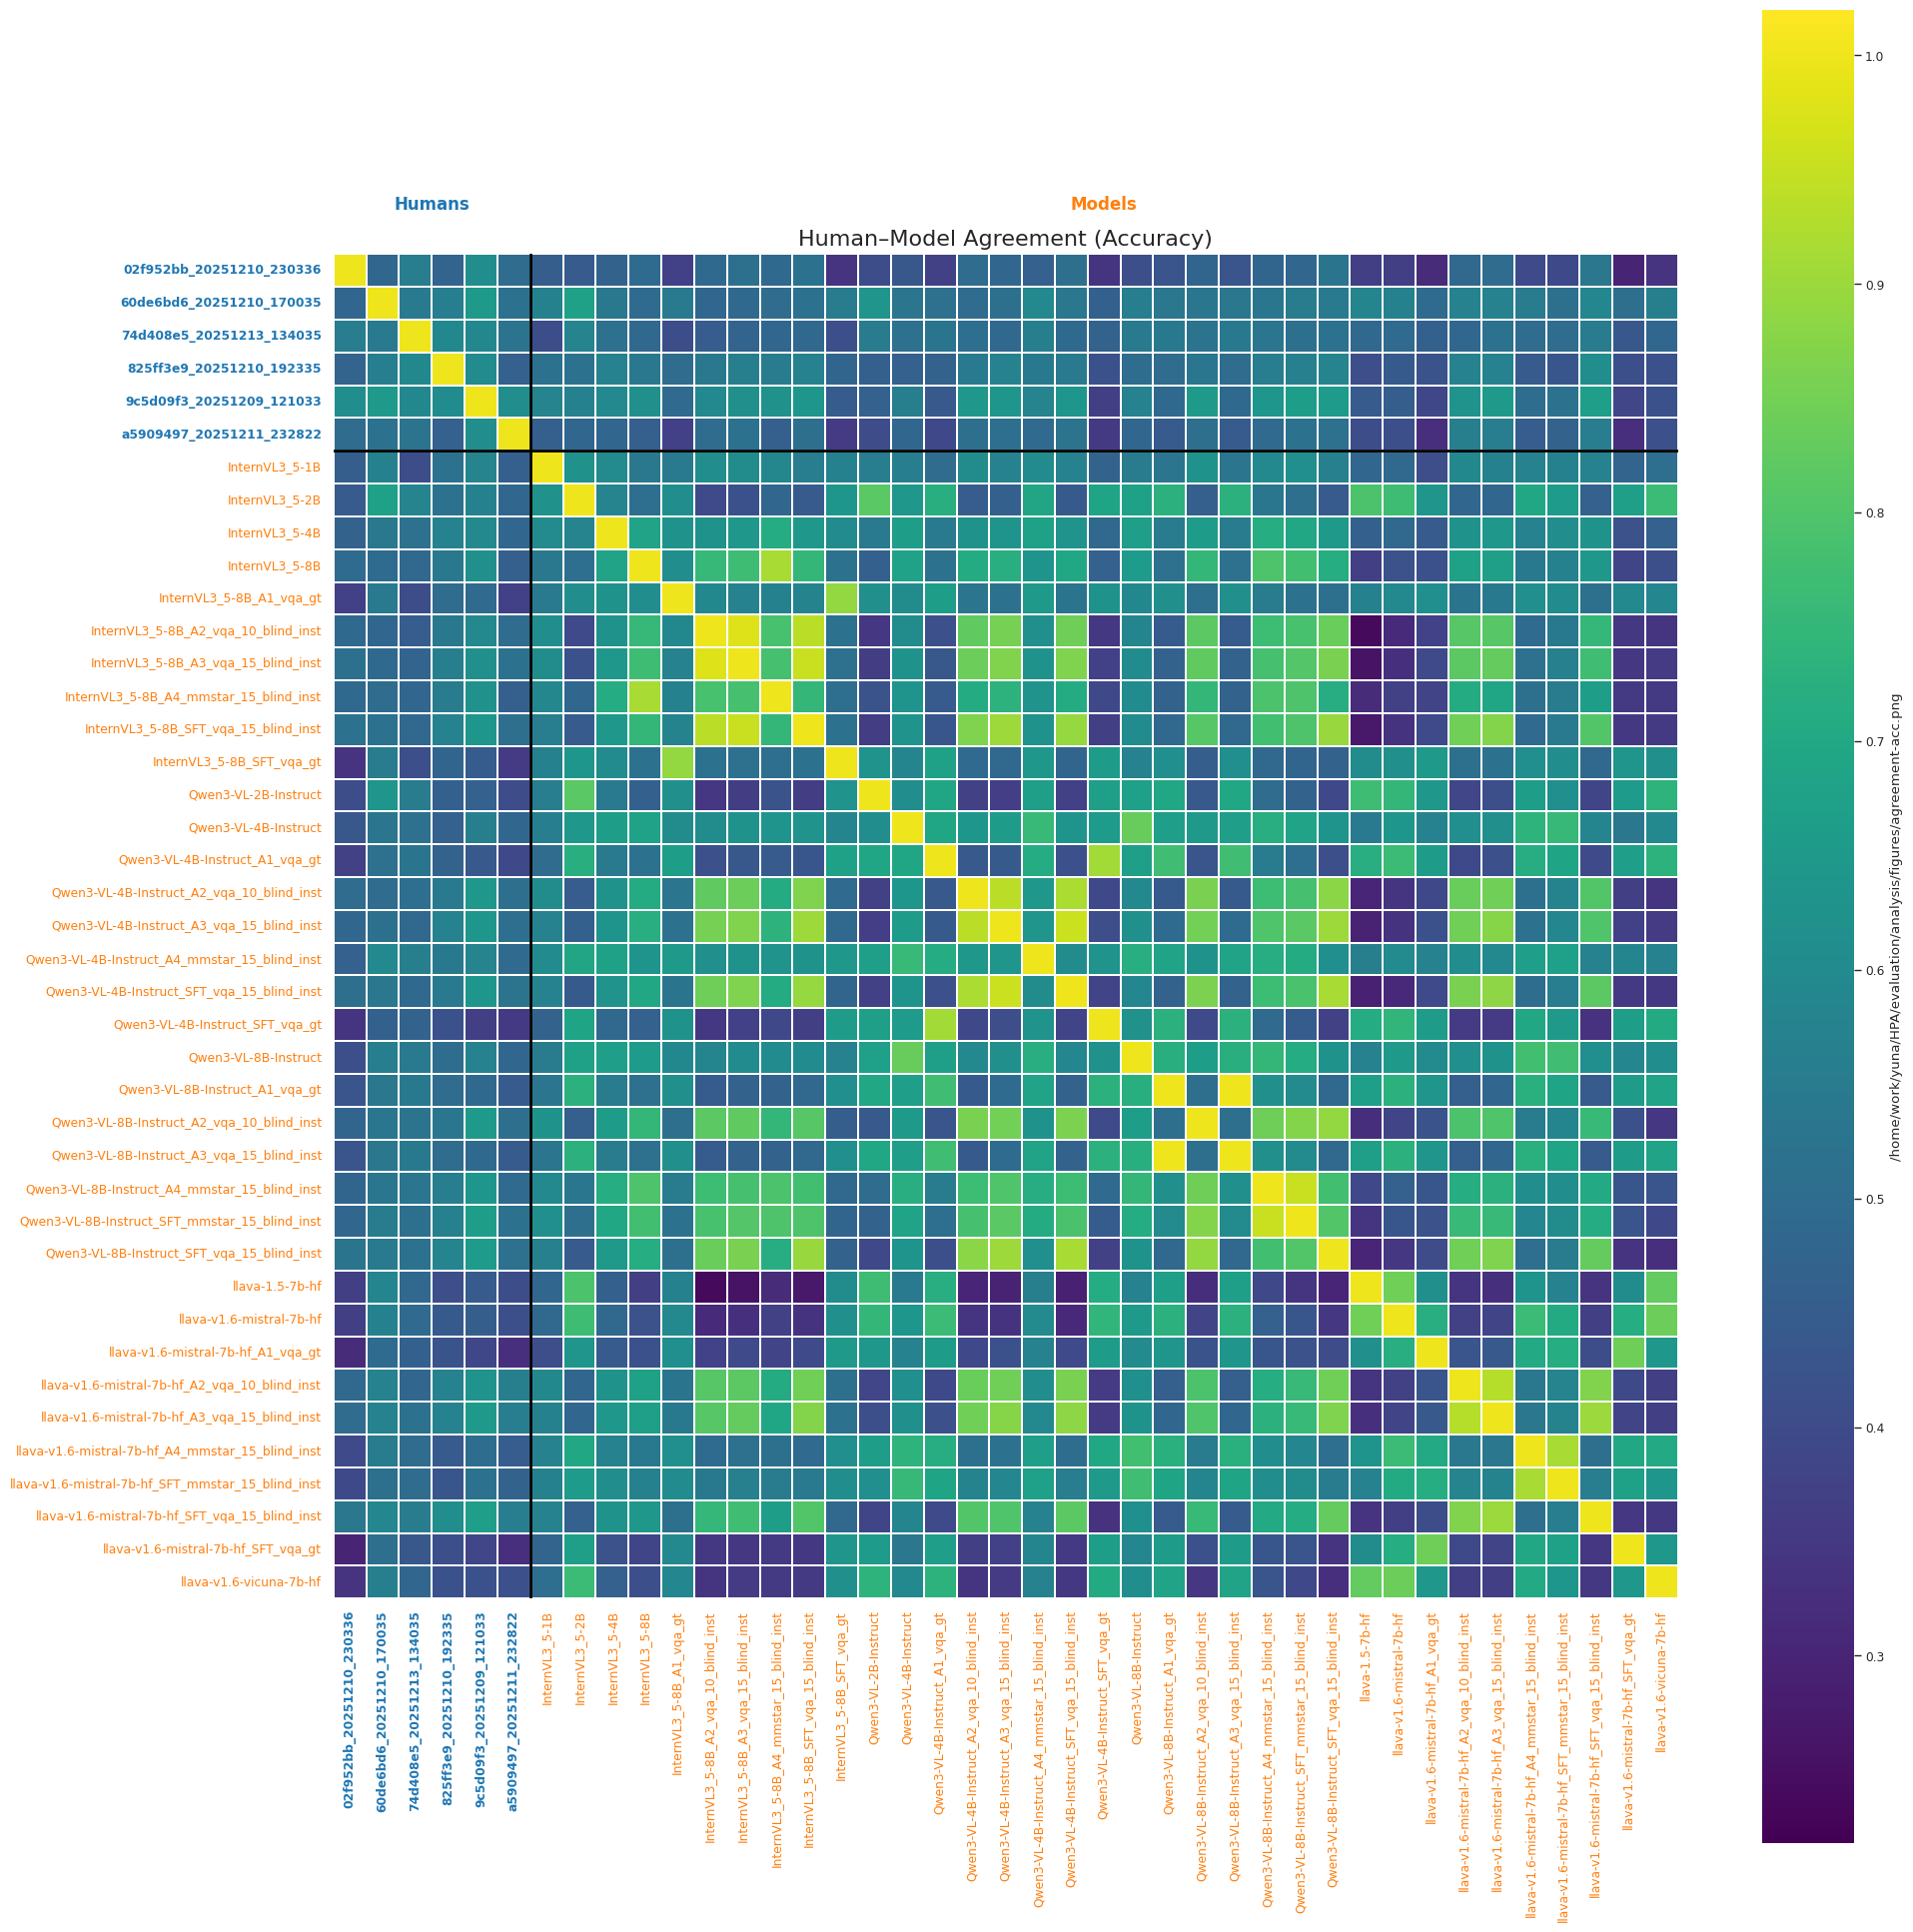

In [538]:
from utils.corr import get_all_cm, get_agreements, transform_corr_table, plot_unified_agreement_heatmap
from utils.df import result_to_df 

res_HH, res_MM, res_HM  = get_agreements(human_vqa, model_vqa, n_boot=0)  # accuarcy 
corr_mat = get_all_cm(res_HH, res_MM, res_HM )
acc_corr = res_HM['corr_mat'].mean().sort_values().reset_index(name='acc_corr') 
plot_unified_agreement_heatmap(corr_mat, res_HH['corr_mat'].columns, res_MM['corr_mat'].columns, 'Human–Model Agreement (Accuracy)', '/home/work/yuna/HPA/evaluation/analysis/figures/agreement-acc.png') 
acc = pd.concat([result_to_df(res_HH), result_to_df(res_MM), result_to_df(res_HM)]) 

res_HH['corr_mat'].mean().reset_index().to_csv('./corr/acc-humans-n6.csv', encoding="utf-8-sig")
res_MM['corr_mat'].mean().reset_index().to_csv('./corr/acc-models-toM.csv', encoding="utf-8-sig")
res_HM['corr_mat'].mean().reset_index().to_csv('./corr/acc-models-toH-n6.csv', encoding="utf-8-sig")

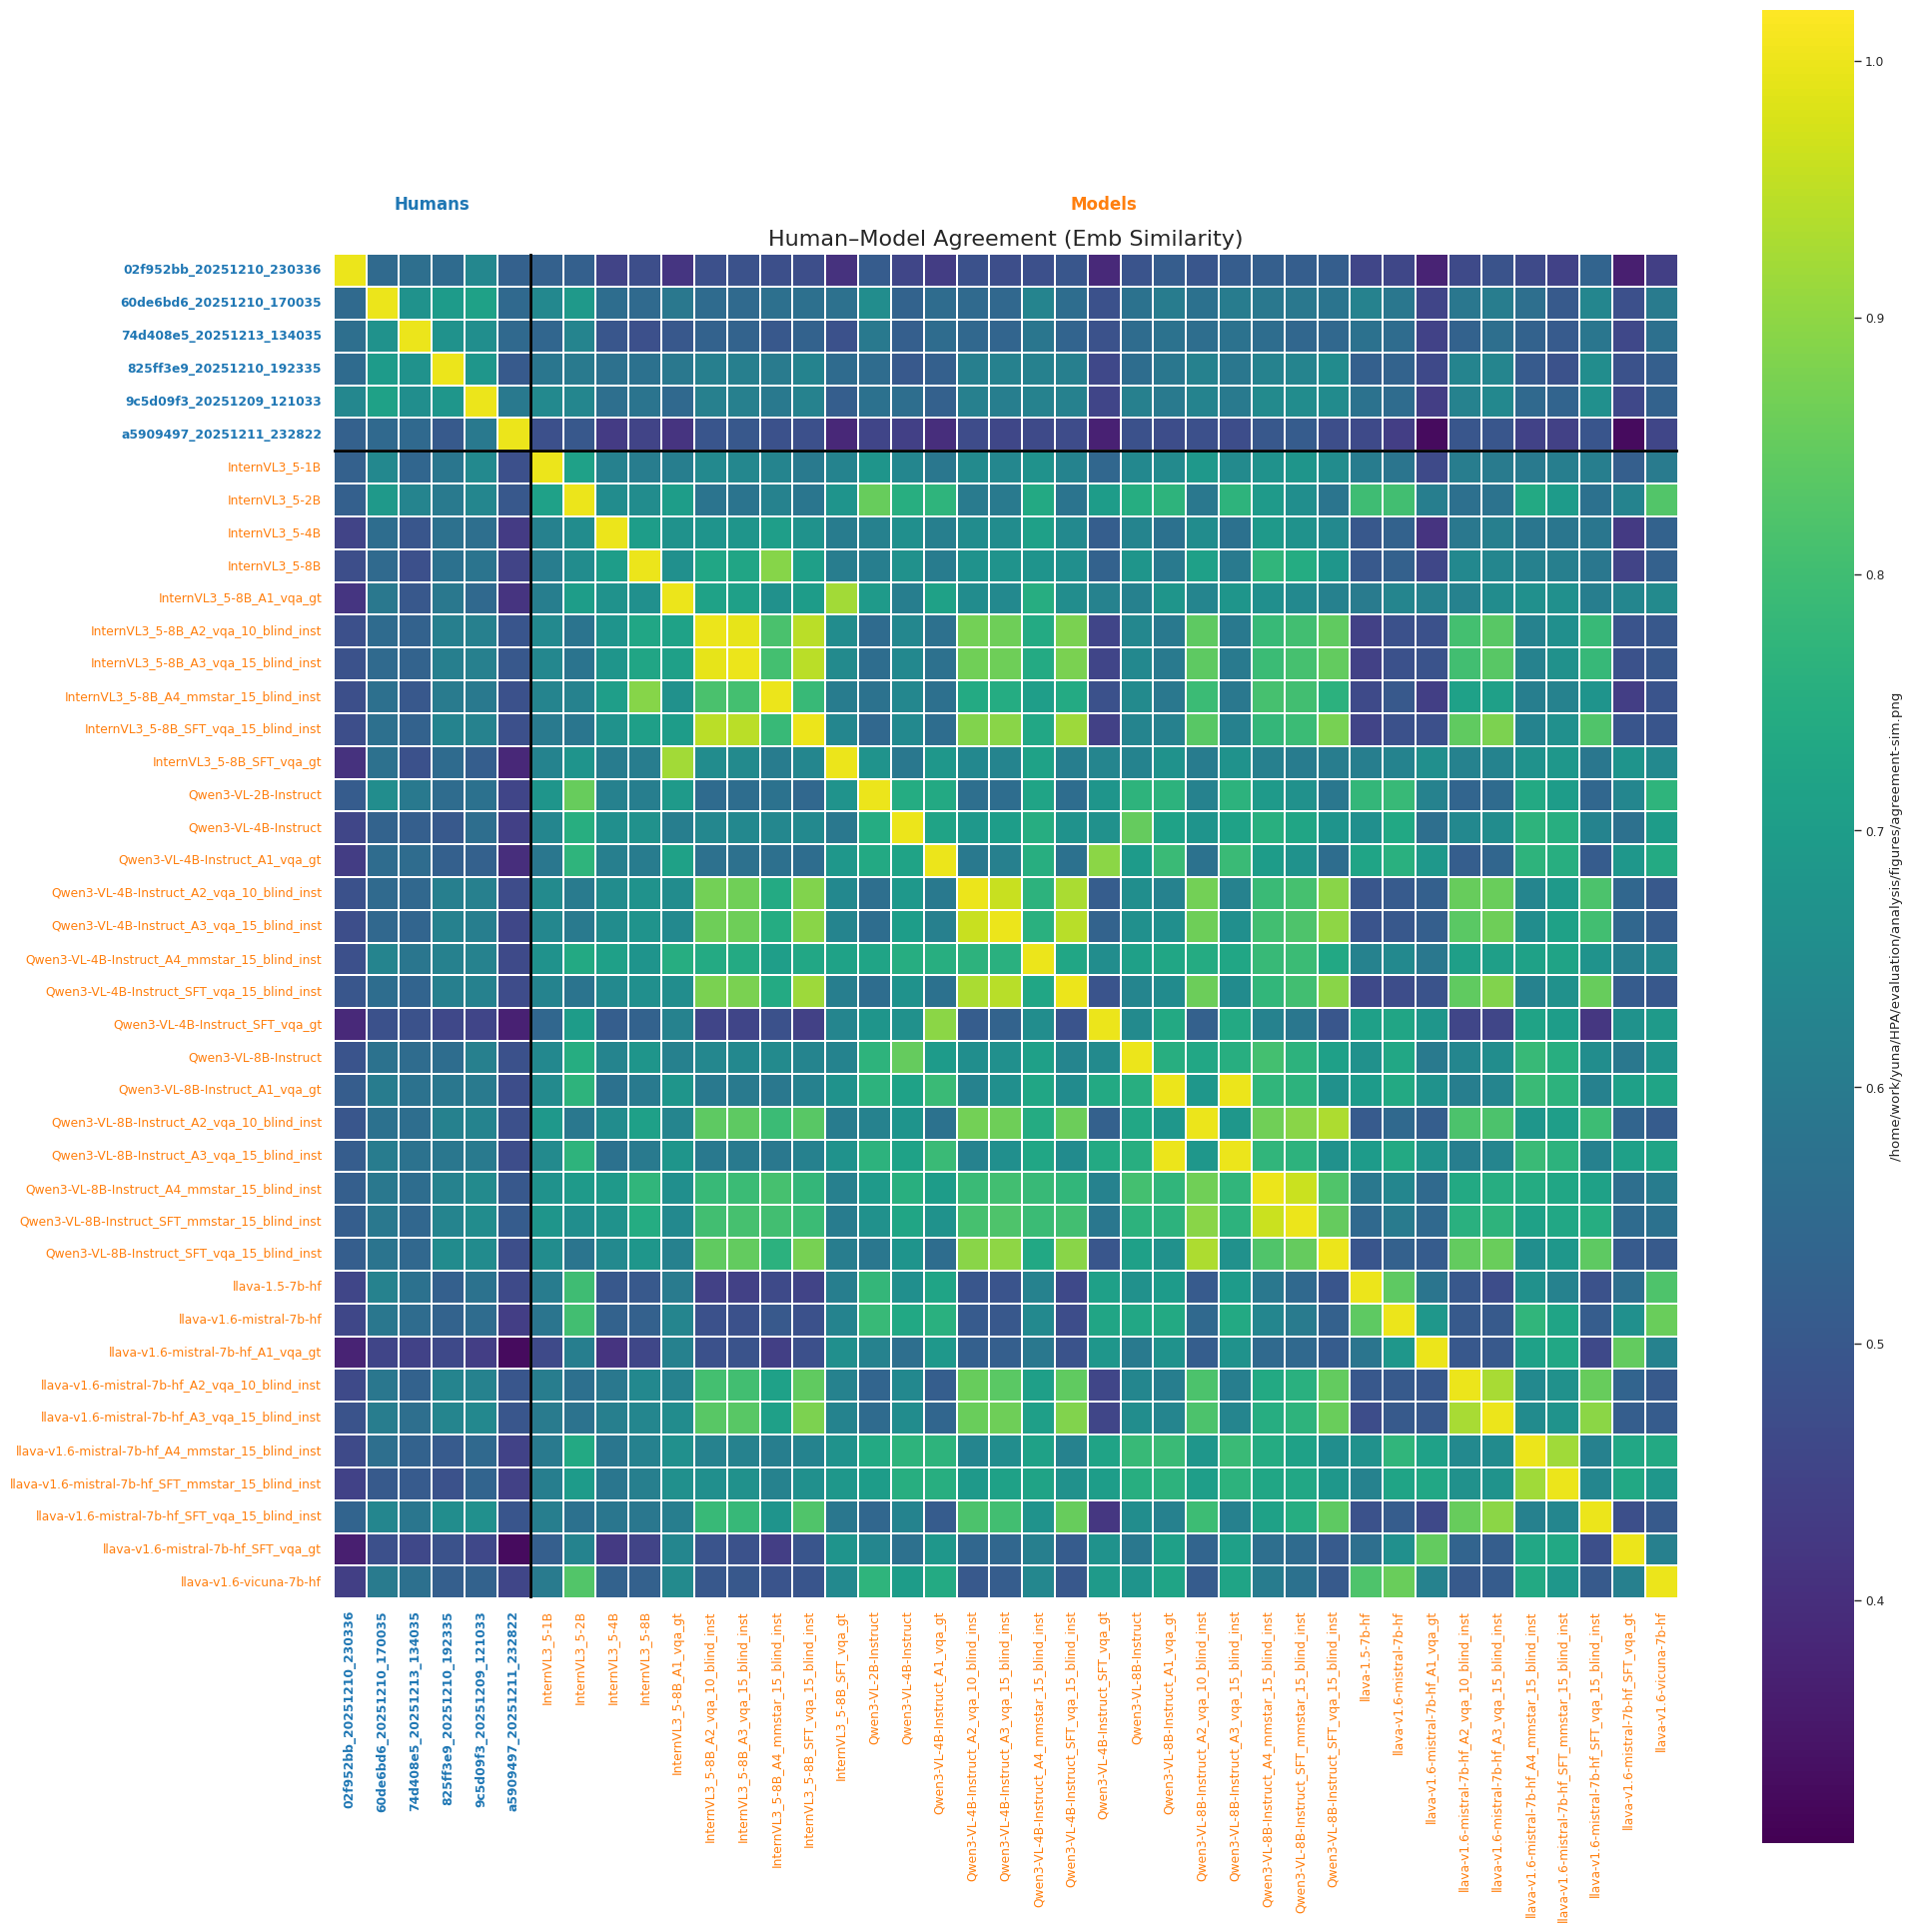

signal,Accuracy $\rho$,Embedding $\rho$
comparison,,
Human–Human,"0.553 [0, 0]","0.611 [0, 0]"
Human–Model,"0.503 [0, 0]","0.536 [0, 0]"
Model–Model,"0.63 [0, 0]","0.69 [0, 0]"


In [ ]:
res_HH, res_MM, res_HM  =  get_agreements(human_vqa, model_vqa, 'answer_similarity', n_boot=0) 
corr_mat = get_all_cm(res_HH, res_MM, res_HM ) 
sim_corr = res_HM['corr_mat'].mean().sort_values().reset_index(name='sim_corr') 
pcorr = pd.merge(acc_corr, sim_corr, on =['model']) 
acc = pd.concat([acc, result_to_df(res_HH), result_to_df(res_MM), result_to_df(res_HM)])
plot_unified_agreement_heatmap(corr_mat,  res_HH['corr_mat'].columns, res_MM['corr_mat'].columns, 'Human–Model Agreement (Emb Similarity)', '/home/work/yuna/HPA/evaluation/analysis/figures/agreement-sim.png') 
transform_corr_table(acc) # .to_latex('./tables/appendix/3_spearman-interrater-vqa-finetuned.tex', float_format="%.3f")   

In [328]:
# Calculate MG = condition['inst_blind'] - condition[''] within the same model in vqa_5k
mg_df = vqa_5k.pivot_table(
    index='model',
    columns='condition',
    values=['correct', 'answer_similarity'],  # or whatever metric you want to use for MG, e.g. "MG_Acc" or "MG_S"
)

mg_df[("MG_Acc", "")] = (
    mg_df[("correct", "")]
    - mg_df[("correct", "inst blind")]
)

mg_df[("MG_S", "")] = (
    mg_df[("answer_similarity", "")]
    - mg_df[("answer_similarity", "inst blind")]
)
mg_df = mg_df.reset_index()

mg_df[['model', 'MG_Acc', 'MG_S']].to_csv('./5k-vqa-mg.csv', encoding="utf-8-sig")

In [ ]:
pcorr = pd.merge(acc_corr, sim_corr, on =['model']) 
pcorr['model'] = pcorr['model'].map(MODEL_DISPLAY_MAP)
if isinstance(mg_df.columns, pd.MultiIndex):
    mg_df.columns = ['_'.join(str(c) for c in col if c != '') for col in mg_df.columns.values]
pcorr= pd.merge(pcorr.reset_index(), mg_df.reset_index(), on=['model'])  
pcorr = pcorr[~pcorr['model'].str.contains('MMStar')]
pcorr = pcorr[['model', 'acc_corr', 'sim_corr', 'MG_Acc', 'MG_S']]

pcorr['family'] = pcorr['model'].map(get_family)
pcorr['model_size'] = pcorr['model'].map(parse_size)  
pcorr['regime'] = pcorr['model'].str.split('|').str[1]
pcorr["regime"] = (
    pcorr["regime"]
    .str.replace("\u2011", "-", regex=False)  # non‑breaking hyphen
    .str.replace("\u2013", "-", regex=False)  # en dash
    .str.replace("\u2014", "-", regex=False)  # em dash
    # .str.replace(" (n=10)", "")  # em dash
    # .str.replace(" (n=15)", "")  # em dash
    .str.strip()
)
pcorr = pcorr.fillna('Pretrained')
pcorr.to_csv('./all_models-corr.csv', encoding="utf-8-sig")
pcorr.regime.unique() 

In [ ]:
import pandas as pd
from utils.corr import corr_by_regime

exclude_models = [
    "LLaVA‑Vicuna‑7B", "Qwen3‑VL‑2B", "LLaVA‑1.5‑7B",
    "InternVL3.5‑1B", "InternVL3.5‑2B", "InternVL3.5‑4B",
]
pcorr = pcorr[~pcorr['model'].str.contains('|'.join(exclude_models))]
corr_by_regime(pcorr).to_latex('./tables/appendix/finetuned-pearson-r.tex', float_format="%.1f")    

JS-Blind VQA (n=10) ['InternVL3.5‑8B | JS‑Blind VQA (n=10)'
 'Qwen3‑VL‑4B | JS‑Blind VQA (n=10)' 'Qwen3‑VL‑8B | JS‑Blind VQA (n=10)'
 'LLaVA‑Mistral‑7B | JS‑Blind VQA (n=10)']
JS-Blind VQA (n=15) ['Qwen3‑VL‑8B | JS‑Blind VQA (n=15)'
 'InternVL3.5‑8B | JS‑Blind VQA (n=15)'
 'Qwen3‑VL‑4B | JS‑Blind VQA (n=15)'
 'LLaVA‑Mistral‑7B | JS‑Blind VQA (n=15)']
Pretrained ['LLaVA‑Mistral‑7B' 'Qwen3‑VL‑4B' 'Qwen3‑VL‑8B' 'InternVL3.5‑8B']
SFT-Blind VQA ['InternVL3.5‑8B | SFT‑Blind VQA' 'Qwen3‑VL‑4B | SFT‑Blind VQA'
 'Qwen3‑VL‑8B | SFT‑Blind VQA' 'LLaVA‑Mistral‑7B | SFT‑Blind VQA']
SFT-VQA ['LLaVA‑Mistral‑7B | SFT‑VQA' 'Qwen3‑VL‑4B | SFT‑VQA'
 'InternVL3.5‑8B | SFT‑VQA']


,Regime,models,Pearson r,Spearman ρ,R²
0,JS-Blind VQA (n=10),4,-0.203301,-0.2,0.041331
1,JS-Blind VQA (n=15),4,-0.869291,-0.8,0.755667
2,Pretrained,4,0.223755,-0.2,0.050066
3,SFT-Blind VQA,4,-0.741559,-0.4,0.549909
4,SFT-VQA,3,-0.376414,-0.5,0.141688


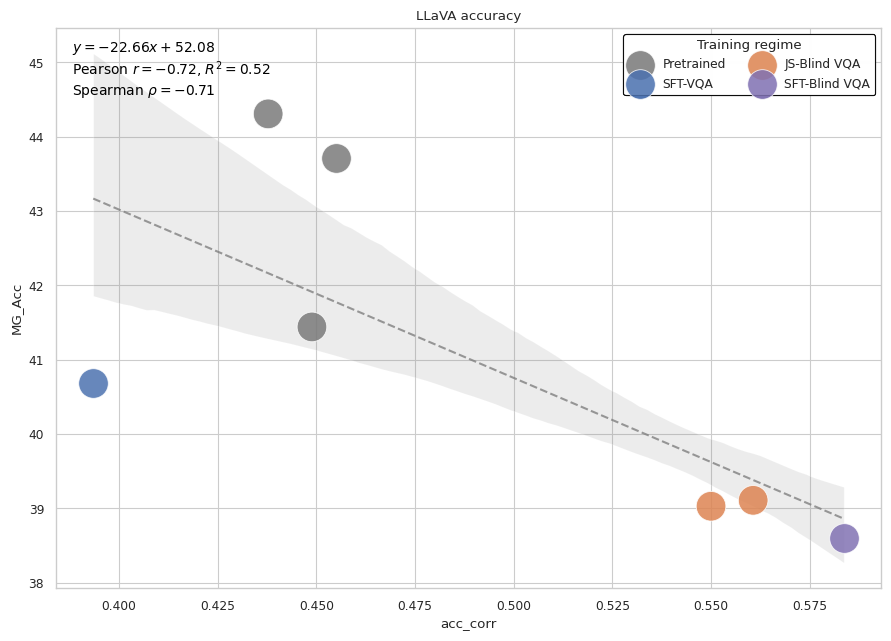

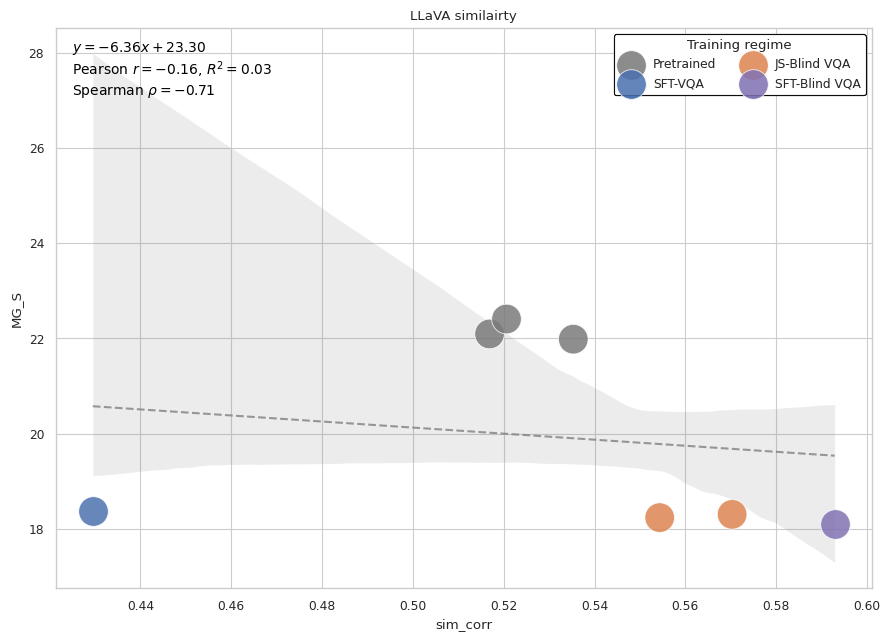

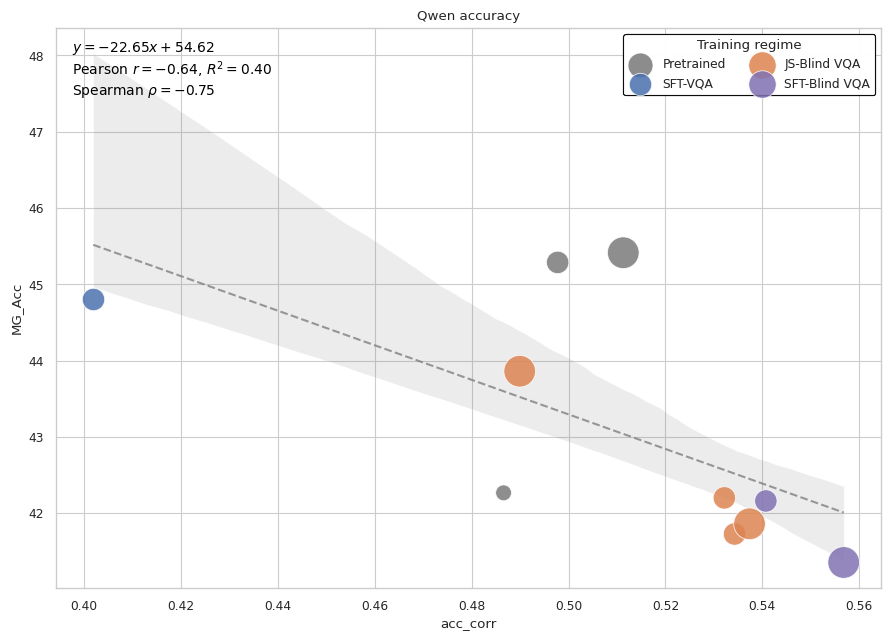

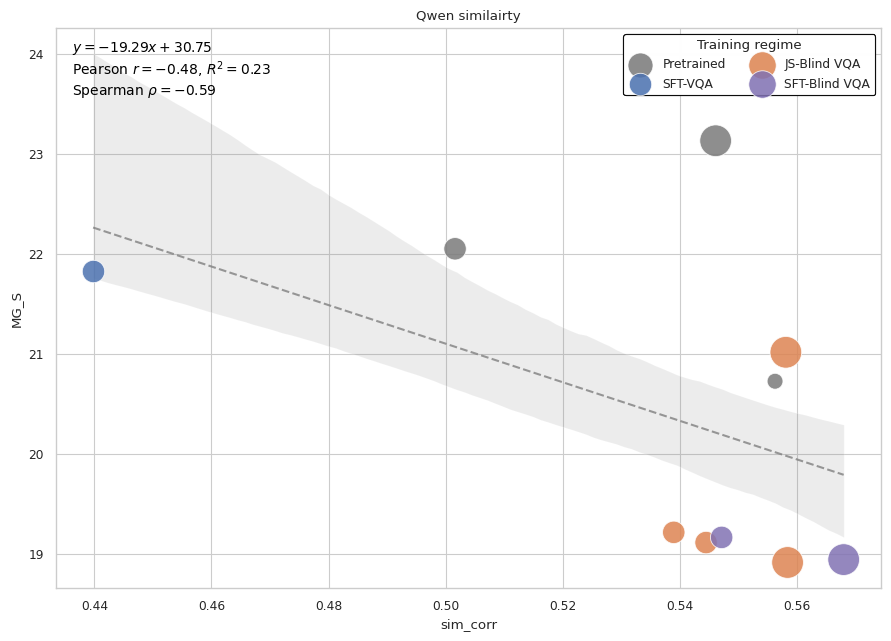

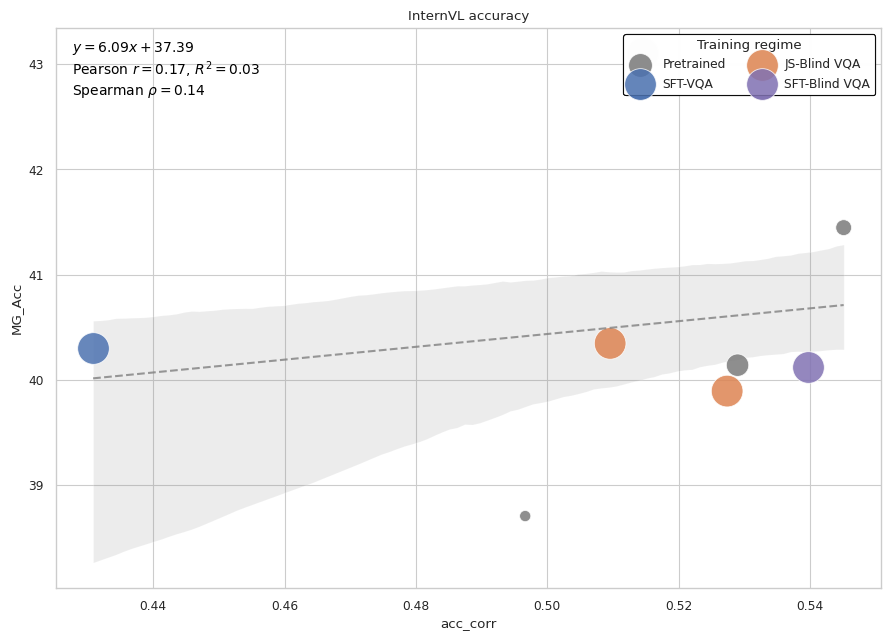

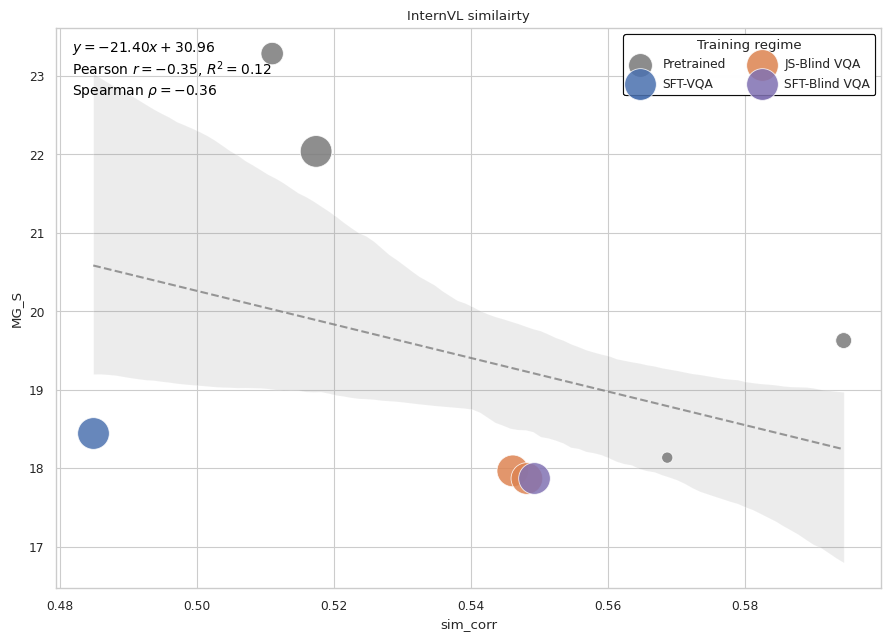

In [ ]:
# from utils.plots import scatterplot, get_family, parse_size 
from utils.plots import scatterplot_finetuned 

for fam in pcorr.family.unique(): 
    scatterplot_finetuned(pcorr[(pcorr['family'] == fam) ] , x_col='acc_corr', y_col='MG_Acc', title=f'{fam} accuracy') # 
    scatterplot_finetuned(pcorr[(pcorr['family'] == fam) ] , x_col='sim_corr', y_col='MG_S', title=f'{fam} similairty') # 

In [156]:
from utils.plots import scatterplot, get_family, parse_size  
# from utils.df import aggregate_vqa, model_name_map, calculate_mg  

mg_df.columns = [
    col[0] if isinstance(col, tuple) else col
    for col in mg_df.columns
]
pcorr = pd.merge(acc_corr, sim_corr, on =['model']) 
pcorr 

,model,acc_corr,sim_corr
0,llava-v1.6-mistral-7b-hf_SFT_vqa_gt,0.393473,0.429499
1,llava-v1.6-mistral-7b-hf_A1_vqa_gt,0.401660,0.416567
2,Qwen3-VL-4B-Instruct_SFT_vqa_gt,0.401851,0.439777
3,InternVL3_5-8B_SFT_vqa_gt,0.430859,0.484900
4,llava-v1.6-vicuna-7b-hf,0.437786,0.516886
5,InternVL3_5-8B_A1_vqa_gt,0.447289,0.509137
6,llava-1.5-7b-hf,0.448877,0.535330
7,Qwen3-VL-4B-Instruct_A1_vqa_gt,0.451828,0.497858
8,llava-v1.6-mistral-7b-hf,0.455098,0.520616
9,llava-v1.6-mistral-7b-hf_SFT_mmstar_15_blind_inst,0.471630,0.487363


In [657]:
df.spurious_correlation_type_annot.unique()

array(['Shape', 'Background', 'Co-occurring Objects', 'Orientation',
       'Colorization', 'Texture and Noise', 'Lighting and Shadows',
       'Relative Size', 'Perspective and Angle', 'Context', 'Packaging',
       'Position', 'Material', 'Size', 'Appearance', 'Motion Blur'],
      dtype=object)

In [ ]:
import re

def parse_finetuned(s):
    return pd.Series({
        'trainer': 'JS' if 'JS' in s else 'SFT',
        'supervision': 'Blind' if 'Blind' in s else 'GT',
        'dataset': 'MMStar' if 'MMStar' in s else 'VQA',
        'n': int(re.search(r'n=(\d+)', s).group(1)) if 'n=' in s else None
    })

meta = df['finetuned'].apply(parse_finetuned)
df2 = pd.concat([df, meta], axis=1)
pt = (
    df2.groupby(['model', 'trainer', 'supervision', 'dataset'])['delta']
       .mean()
       .unstack(['supervision', 'dataset'])
       .round(3)
) 

supervision               Blind            GT
dataset                  MMStar    VQA    VQA
model            trainer                     
InternVL3.5‑8B   JS       0.002  0.002 -0.001
                 SFT        NaN  0.004  0.000
LLaVA‑Mistral‑7B JS      -0.012  0.068 -0.004
                 SFT     -0.015  0.028 -0.064
Qwen3‑VL‑4B      JS       0.004  0.002  0.000
                 SFT        NaN -0.011 -0.011
Qwen3‑VL‑8B      JS       0.000  0.007 -0.012
                 SFT      0.024 -0.012    NaN

In [678]:
pt.to_latex(
    './tables/4_finetune_delta_pivot.tex',
    float_format="%.3f",
    multicolumn=True,
    multirow=True
)

In [675]:
df = pd.merge(bs,ft, on=['model', 'pid', "bias"], how='right', suffixes=("_baseline", "")).dropna(axis=1) 
df['delta'] = df['correct_baseline'].astype(float) - df['correct'].astype(float)
df=df[['model', 'finetuned', 'pid', 'bias', 'delta']]
pt = (
    df.groupby(['model', 'finetuned'])['delta']
      .mean()
      .round(3)
) 
pt.to_latex(
    './tables/4_spubench-corr-finetuned-delta.tex',
    float_format="%.3f",
    multirow=True
)

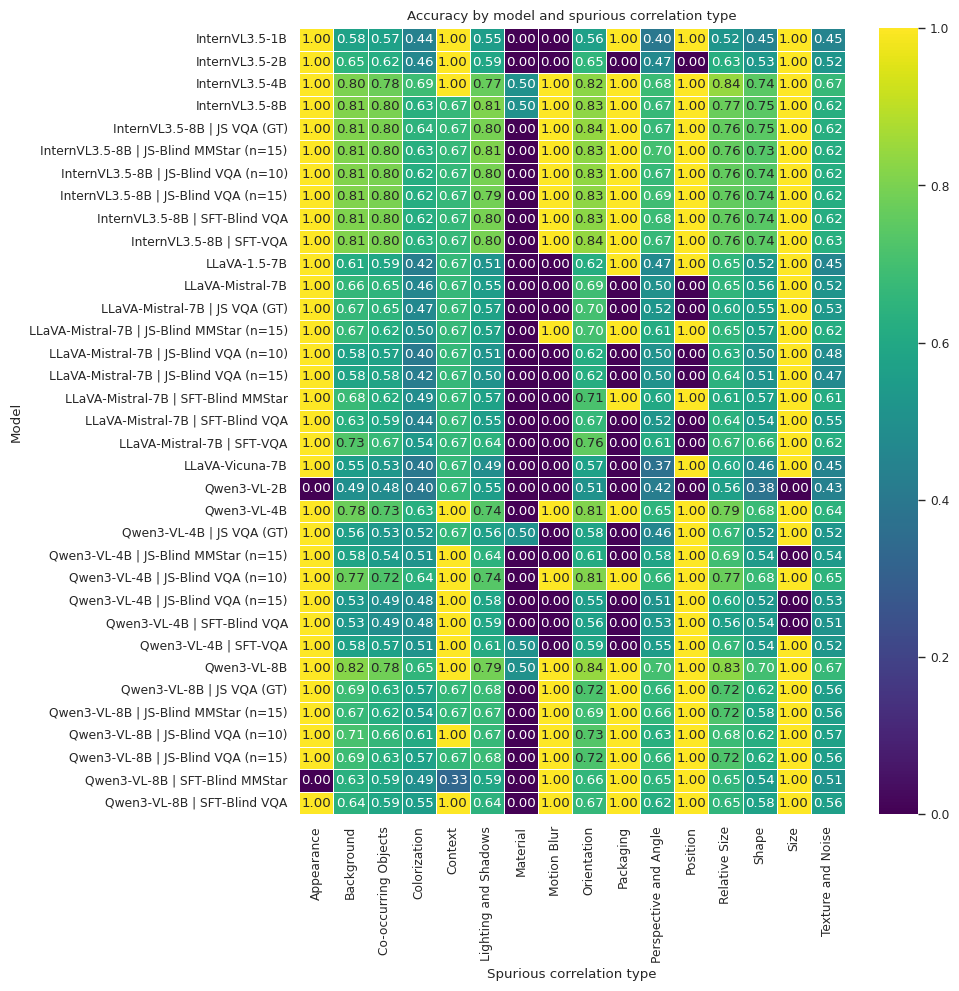

In [572]:
import seaborn as sns
import matplotlib.pyplot as plt

df = df.explode('spurious_correlation_type_annot')
pt= df.pivot_table(index=['model'], 
            columns='spurious_correlation_type_annot', 
            values='correct') # , aggfunc=['mean'] 

plt.figure(figsize=(10, 10))
sns.heatmap(
    pt,
    annot=True,
    fmt=".2f",
    cmap="viridis",
    vmin=0, vmax=1,
    linewidths=0.5
)
plt.ylabel("Model")
plt.xlabel("Spurious correlation type")
plt.title("Accuracy by model and spurious correlation type")
plt.tight_layout()
plt.show()

In [ ]:
count_df = df.groupby(['spurious_correlation_type', 'model'])['correct'].count().reset_index(name='count')
valid_pairs = count_df[count_df['count'] > 10][['spurious_correlation_type', 'model']]
filtered_df = df.merge(valid_pairs, on=['spurious_correlation_type', 'model'], how='inner')

In [229]:
with open('/home/work/yuna/HPA/evaluation/scored/humans/human_mc_per_question.json', 'r') as f:
    raw_data = json.load(f) 
human_mc = pd.DataFrame(raw_data)
df = human_mc.rename(columns={'\ufeffquestion_num': 'question_num'}) 
qids = human_mc.pid.unique()   
human_mc['question_id'] = human_mc['pid'].astype('Int64') 
human_mc['model'] = 'Humans'
human_mc['correct'] = human_mc['correct'] * 100
# human_mc= human_mc[human_mc['participant_id']!= '13f54aa2_20251204_125847'] 
trainh = human_mc[human_mc['participant_id'].isin(pids)] 
human_mc = human_mc[~human_mc['participant_id'].isin(pids)] 
len(trainh.participant_id.unique()) , len(human_mc.participant_id.unique()) 

(15, 6)

In [ ]:
model_mc = get_summary('mmstar')
model_mc['question_id'] = model_mc['pid'].astype('Int64') 
model_mc = model_mc.drop_duplicates(subset=['model', 'question_id', 'condition']) 
model_mc['model'] = model_mc['model'].map(MODEL_DISPLAY_MAP)  
blind_model=model_mc[model_mc['condition'] == 'inst blind']
print(model_mc.model.unique(), model_mc.condition.unique()) 
mmstar_blind = pd.concat([blind_model[blind_model['pid'].isin(qids)], human_mc])
mmstar_blind.to_csv('./finetuned-mmstar-subset.csv')
mmstar_blind.groupby(['model']).count()

In [255]:
pt = pd.concat([model_mc,human_mc]).pivot_table(
    index=['model', 'category', 'l2_category', 'question_id'], # , 'output', 'question' 
    values='correct',
    columns='condition',
    aggfunc='mean'
)
pt['Acc_Visual'] = pt['']
pt['Acc_Blind_inst'] = pt['inst blind']
pt['MG_Acc'] = pt[''] - pt['inst blind']
pt['Delta_Inst'] = pt['blind'] - pt['inst blind']
pt = pt.reset_index()
pt.to_csv('./all_mmstar_models-qs-mg.csv')

In [256]:
pt.groupby(['model']).mean(numeric_only=True).drop(columns=['', 'blind', 'inst blind']).to_latex(
            f'./mmstar-mg-finetuned-by-models.tex', float_format="%.1f"
        )

In [260]:
pt[pt['question_id'].isin(qids)].pivot_table(
    index=['model'], 
    values='MG_Acc',
    columns=['category', 'l2_category'],
    aggfunc='mean'
).to_latex(f'./tables/4_mmstar-mg-finetuned-catl2-subset.tex', float_format="%.1f")  

In [261]:
pt[pt['question_id'].isin(qids)].pivot_table(
    index=['model'], 
    values='MG_Acc',
    columns=['category'],
    aggfunc='mean'
).to_latex(f'./tables/4_mmstar-mg-finetuned-cat-subset.tex', float_format="%.1f")  

In [311]:
from utils.corr import plot_unified_agreement_heatmap  # get_agreements
from utils.ac1 import interrater_agreement_ac1 

metrics='correct' 
n_boot=200 
human_acc = human_mc.drop_duplicates(subset=['question_id', 'participant_id']).pivot(
        index=["category", "l2_category", "question_id"],
        columns="participant_id",
        values=metrics
    )
model_acc = blind_model.pivot_table( # .drop_duplicates(subset=['model', 'question_id'])
    index=["category", "l2_category", "question_id"], 
    columns="model",
    values=metrics, 
    aggfunc='mean'
) 
answers_pivot = human_acc.join(model_acc, how="inner").reset_index() 
humans = human_acc.columns
models = model_acc.columns

In [314]:
category_corr = []
for category in answers_pivot.category.unique():  

    for l2_category in answers_pivot.l2_category.unique():  
        res = interrater_agreement_ac1(
            answers_pivot[(answers_pivot['category'] == category) &(answers_pivot['l2_category'] ==  l2_category)],
            grp1=humans,
            grp2=models,
            n_boot=0,
            ) 
        res['category'] = category 
        res['l2_category'] = l2_category 
        category_corr.append(res)
category_corr = pd.DataFrame(category_corr)


In [ ]:
category_corr.dropna(subset=['mean_r']).to_csv(f"./tables/appendix/mmstar-ac1-l2category.csv", encoding="utf-8-sig") 
category_corr.to_latex(f"./tables/appendix/mmstar-ac1-category.tex", float_format="%.1f")  

In [303]:
model_corr = [] 
for i, cc in category_corr.iterrows(): 
    corr_mat=cc['corr_mat'].T.reset_index().melt(id_vars=['model'], var_name='subj', value_name='corr')    
    corr_mat['category'] = cc['category']
    model_corr.append(corr_mat) 
model_corr= pd.concat(model_corr)
model_corr.dropna()

,model,subj,corr,category
0,InternVL3.5‑1B,02f952bb_20251210_230336,0.448276,coarse perception
1,InternVL3.5‑2B,02f952bb_20251210_230336,0.623698,coarse perception
2,InternVL3.5‑4B,02f952bb_20251210_230336,0.490885,coarse perception
3,InternVL3.5‑8B,02f952bb_20251210_230336,0.480916,coarse perception
4,InternVL3.5‑8B | JS‑Blind MMStar (n=15),02f952bb_20251210_230336,0.540230,coarse perception
...,...,...,...,...
205,Qwen3‑VL‑8B | JS‑Blind VQA (GT),a5909497_20251211_232822,-0.090090,logical reasoning
206,Qwen3‑VL‑8B | JS‑Blind VQA (n=10),a5909497_20251211_232822,0.000000,logical reasoning
207,Qwen3‑VL‑8B | JS‑Blind VQA (n=15),a5909497_20251211_232822,-0.090090,logical reasoning
208,Qwen3‑VL‑8B | SFT‑Blind MMStar,a5909497_20251211_232822,0.141844,logical reasoning


In [323]:
model_corr.groupby(['model', 'category'])['corr'].mean().reset_index().to_csv('./corr-mmstar-MH-cat.csv', encoding="utf-8-sig")